# n-Butane Rotational PES Exercise

From **Chris Cramer, CompChem.02.01** — *The Potential Energy Surface*  
Video: https://www.youtube.com/watch?v=pu4uL7deCNw

**Author:** Nazanin Soleimani

## Exercise (lecture slide)

1. Draw and label a **relaxed** butane rotational reaction coordinate  
2. Overlay energy with other DOF fixed at the **trans (anti)** geometry  
3. Overlay energy with other DOF fixed at the **gauche** geometry  
4. Internal-coordinate PES vs Cartesian-coordinate PES — how do they differ?

Run cells top to bottom with **Shift + Enter**.

## STEP 0 - Setup

In [1]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem

PROJECT = Path(r"C:\Users\nazan\Documents\Pyton Projects\Butane-PES-Exercise")
os.chdir(PROJECT)
RESULTS = PROJECT / "results"
RESULTS.mkdir(exist_ok=True)
print("Working directory:", Path.cwd())
print("STEP 0 finished OK")

Working directory: C:\Users\nazan\Documents\Pyton Projects\Butane-PES-Exercise
STEP 0 finished OK


## STEP 1 - What is the reaction coordinate?

For n-butane, the classic 1-D reaction coordinate is the **C1-C2-C3-C4 dihedral angle** (rotation about the central C2-C3 bond).

- **Relaxed scan:** at each dihedral angle, optimize *all other* degrees of freedom  
- **Rigid scan:** change only the dihedral; keep bond lengths/angles frozen at a reference conformer

## STEP 2 - Build n-butane and helper functions (MMFF94)

In [2]:
def make_butane():
    mol = Chem.MolFromSmiles("CCCC")
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol, randomSeed=42)
    AllChem.MMFFOptimizeMolecule(mol)
    return mol


def mmff_energy(mol):
    props = AllChem.MMFFGetMoleculeProperties(mol, mmffVariant="MMFF94")
    ff = AllChem.MMFFGetMoleculeForceField(mol, props)
    return ff.CalcEnergy()  # kcal/mol


def set_dihedral(mol, angle_deg):
    conf = mol.GetConformer()
    Chem.rdMolTransforms.SetDihedralDeg(conf, 0, 1, 2, 3, float(angle_deg))


def optimize_with_fixed_dihedral(mol, angle_deg, max_its=500):
    m = Chem.Mol(mol)
    set_dihedral(m, angle_deg)
    props = AllChem.MMFFGetMoleculeProperties(m, mmffVariant="MMFF94")
    ff = AllChem.MMFFGetMoleculeForceField(m, props)
    ff.MMFFAddTorsionConstraint(0, 1, 2, 3, False, float(angle_deg), float(angle_deg), 1.0e5)
    ff.Minimize(maxIts=max_its)
    return m, ff.CalcEnergy()


def rigid_energy_from_reference(ref_mol, angle_deg):
    m = Chem.Mol(ref_mol)
    set_dihedral(m, angle_deg)
    return mmff_energy(m)


base = make_butane()
print("n-butane atoms:", base.GetNumAtoms())
print("Energy (optimized) =", mmff_energy(base), "kcal/mol")
print("STEP 2 finished OK")

n-butane atoms: 14
Energy (optimized) = -4.293764273523254 kcal/mol
STEP 2 finished OK


## STEP 3 - Run relaxed + rigid scans (parts 1–3)

In [3]:
angles = np.arange(-180.0, 180.0 + 0.1, 5.0)

print("Relaxed scan...")
relaxed_E = []
relaxed_mols = []
for ang in angles:
    m, e = optimize_with_fixed_dihedral(base, ang)
    relaxed_E.append(e)
    relaxed_mols.append(m)
relaxed_E = np.array(relaxed_E)
relaxed_E -= relaxed_E.min()

print("Build anti and gauche references...")
anti_ref, _ = optimize_with_fixed_dihedral(base, 180.0)
gauche_ref, _ = optimize_with_fixed_dihedral(base, 60.0)

print("Rigid scans...")
rigid_anti_E = np.array([rigid_energy_from_reference(anti_ref, a) for a in angles])
rigid_anti_E -= rigid_anti_E.min()

rigid_gauche_E = np.array([rigid_energy_from_reference(gauche_ref, a) for a in angles])
rigid_gauche_E -= rigid_gauche_E.min()

print("Scans complete.")
print("STEP 3 finished OK")

Relaxed scan...
Build anti and gauche references...
Rigid scans...
Scans complete.
STEP 3 finished OK


## STEP 4 - Plot the labeled reaction coordinate

Saved: C:\Users\nazan\Documents\Pyton Projects\Butane-PES-Exercise\results\butane_rotational_pes.png


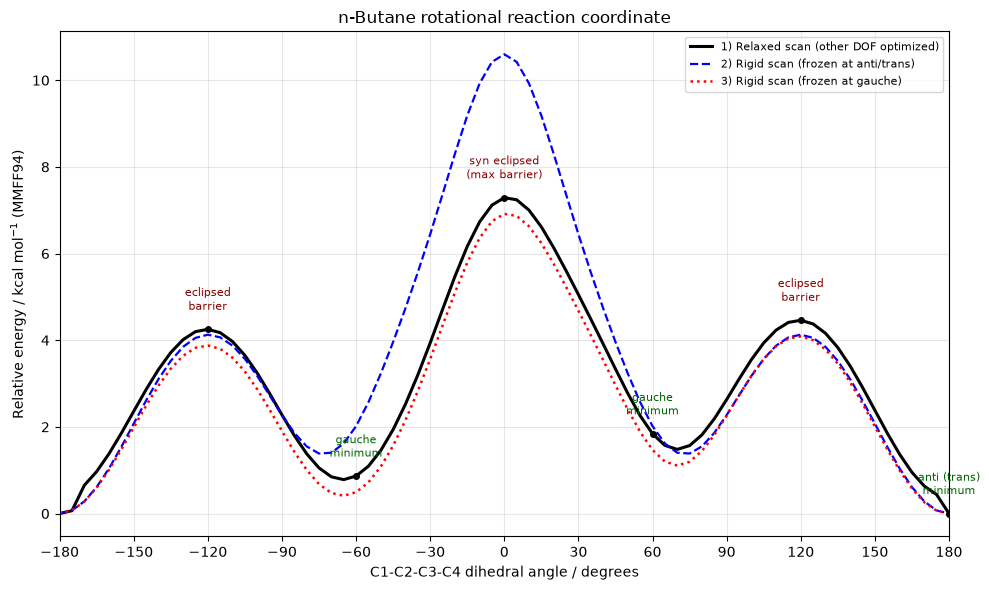

STEP 4 finished OK


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(angles, relaxed_E, "k-", lw=2.2, label="1) Relaxed scan (other DOF optimized)")
ax.plot(angles, rigid_anti_E, "b--", lw=1.6, label="2) Rigid scan (frozen at anti/trans)")
ax.plot(angles, rigid_gauche_E, "r:", lw=1.8, label="3) Rigid scan (frozen at gauche)")

labels = {
    180: ("anti (trans)\nminimum", "darkgreen"),
    60: ("gauche\nminimum", "darkgreen"),
    -60: ("gauche\nminimum", "darkgreen"),
    0: ("syn eclipsed\n(max barrier)", "darkred"),
    120: ("eclipsed\nbarrier", "darkred"),
    -120: ("eclipsed\nbarrier", "darkred"),
}
for ang, (text, color) in labels.items():
    i = int(np.argmin(np.abs(angles - ang)))
    ax.annotate(text, xy=(angles[i], relaxed_E[i]), xytext=(0, 14),
                textcoords="offset points", ha="center", fontsize=8, color=color)
    ax.plot(angles[i], relaxed_E[i], "ko", ms=4)

ax.set_xlabel("C1-C2-C3-C4 dihedral angle / degrees")
ax.set_ylabel("Relative energy / kcal mol$^{-1}$ (MMFF94)")
ax.set_title("n-Butane rotational reaction coordinate")
ax.set_xlim(-180, 180)
ax.set_xticks(np.arange(-180, 181, 30))
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
out = RESULTS / "butane_rotational_pes.png"
plt.savefig(out, dpi=160)
print("Saved:", out)
plt.show()
print("STEP 4 finished OK")

## STEP 5 - Numerical highlights

In [5]:
def E_at(curve, target):
    i = int(np.argmin(np.abs(angles - target)))
    return float(curve[i])

print("Relaxed relative energies (kcal/mol):")
print(f"  anti  ~180 deg: {E_at(relaxed_E, 180):.3f}")
print(f"  gauche ~60 deg: {E_at(relaxed_E, 60):.3f}")
print(f"  syn     ~0 deg: {E_at(relaxed_E, 0):.3f}")
print(f"  eclipsed ~120:  {E_at(relaxed_E, 120):.3f}")
print()
print("Rigid-anti barrier at 0 deg:", f"{E_at(rigid_anti_E, 0):.3f}")
print("Rigid-gauche energy at 0 deg:", f"{E_at(rigid_gauche_E, 0):.3f}")
print("STEP 5 finished OK")

Relaxed relative energies (kcal/mol):
  anti  ~180 deg: 0.000
  gauche ~60 deg: 1.841
  syn     ~0 deg: 7.289
  eclipsed ~120:  4.460

Rigid-anti barrier at 0 deg: 10.598
Rigid-gauche energy at 0 deg: 6.916
STEP 5 finished OK


## STEP 6 - Written answers (parts 1–4)

### 1) Relaxed butane rotational reaction coordinate
- Coordinate: central C–C dihedral **φ** (C1–C2–C3–C4).
- At every φ, optimize all other bonds/angles/torsions.
- **Shape:** global minima at **anti** (φ ≈ ±180°); local minima at **gauche** (φ ≈ ±60°); highest barrier at **syn eclipsed** (φ ≈ 0°); smaller barriers near ±120°.

### 2) Rigid overlay from **trans (anti)**
- Freeze bond lengths/angles of the anti minimum; only rotate φ.
- Barriers are typically **higher** than relaxed: the molecule cannot open angles to relieve steric clash when methyl groups eclipse.

### 3) Rigid overlay from **gauche**
- Same rigid idea, but freeze the **gauche** geometry.
- Curve is distorted vs the anti-rigid scan: low near φ ≈ 60°, often worse near anti/other angles because gauche bond angles are not ideal there.

### 4) Internal coordinates vs Cartesian coordinates
- **Cartesian PES:** 3N coordinates (x,y,z). Energy does not depend on overall translation/rotation, so the surface has flat rigid-body directions and infinitely many copies of the same shape.
- **Internal PES:** bonds, angles, torsions (~3N−6 for nonlinear molecules). Describes **molecular shape only**, so each distinct conformer appears once. Dihedrals are **periodic** (0–360°).
- Chemistry reaction coordinates (like butane rotation) are almost always **internal**, because we care about relative geometry, not where the molecule sits in the lab frame.

### Take-home message from the lecture
A true reaction coordinate is a **relaxed** 1-D slice of the PES (other DOF optimized), not a rigid scan with everything frozen.